# Yields

### Data

Use the data file `../data/treasury_quotes_2025-04-30.xlsx`.

# 1 YTM and Price

The problems in this section ask you to calculate the **yield-to-maturity (YTM)** of various bonds.

You will need to use a nonlinear solver to solve for the YTM.

For any given bond, YTM ($y$) solves...

$$p = \sum_{i=1}^{2n}\frac{Fc/2}{(1+y/2)^i} + \frac{F}{(1+y/2)^{2n}}$$

where
* $p$ is the bond's price.
* $n$ is the number of years to maturity
* $c$ is the coupon rate (a percentage)
* $F$ is the face value. Use $F=100$

#### Solving for YTM
Consider using `fsolve` to solve the yield implicitly from the nonlinear equation. This function is imported with...

`from scipy.optimize import fsolve`

### 1.1

Consider a semiannual bond with the following stylized parameters:
* time-to-maturity of 30 years
* coupon rate: 3%
* Face value of 100

1. Assume the YTM is 5%. Calculate the price.
1. Assume the price is 87. Calculate the YTM.

In [31]:
import numpy as np
import pandas as pd
from scipy.optimize import fsolve

# 1
y, F, c, n = 0.05, 100, 0.03, 30
p = (
    sum(F * c / 2 / (1 + y / 2)**i for i in range(1, 2*n + 1))
    + F / (1 + y / 2)**(2*n)
)
print(f"Q1: Price of the bond: {p:.2f}")

#2
func = lambda y, p, F, c, n: p - (
    sum(F * c / 2 / (1 + y / 2)**i for i in range(1, 2*n + 1))
    + F / (1 + y / 2)**(2 * n)
)

ytm = fsolve(func, 0.05, args=(87, 100, 0.03, 30))[0]
print(f"Q2: Yield to maturity: {ytm*100:.4f}%")


Q1: Price of the bond: 69.09
Q2: Yield to maturity: 3.7231%


### 1.2

### Data
Use the data in the `selected quotes` tab.
* It gives treasury bond data for various maturities, spaced roughly six months apart.
* Feel free to approximate the time-to-maturity to be exactly semiannually if that is easier for the problem below.
* Use the `price` column for the price data in the YTM formula. (No need to worry about "dirty" price, bid, ask, nor accrued interest.)

1. Calculate the yield-to-maturity for each issue. How close are your calculations to the provided column `ytm`?

1. Plot the time-to-maturity (TTM) against the calculated YTM.

The mean difference between calculated and quoted YTM is:  3.1741802913754295e-05


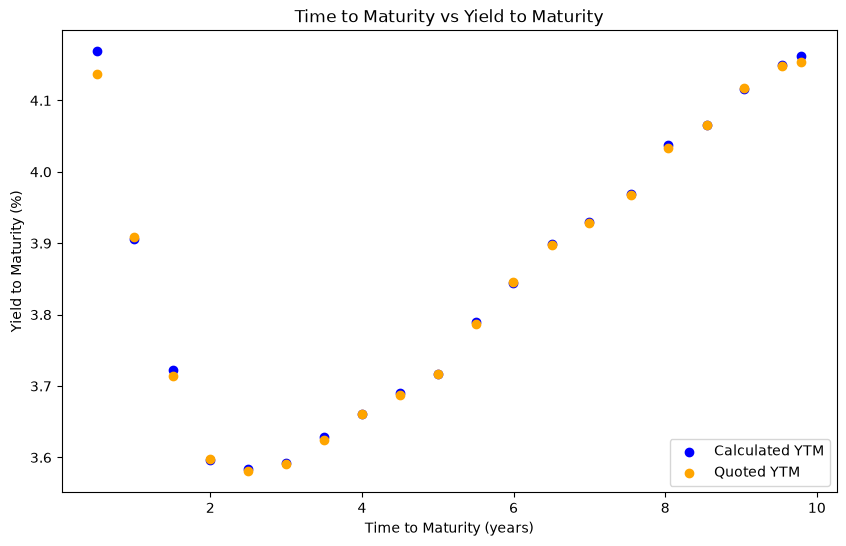

In [36]:
data = pd.read_excel("data/treasury_quotes_2025-04-30.xlsx", sheet_name="selected quotes", index_col=0)

func = lambda y, p, F, c, n: p - (
    sum(F * c / 2 / (1 + y / 2)**i
        for i in range(1, round(2 * n) + 1))
    + F / (1 + y / 2)**round(2 * n)
) # convert to exactly semini annual periods

# 1
price = data["price"].values
face = 100
coupon = data["cpn rate"].values
ttm = data["ttm"].values

data["ytm_calculated"] = [
    fsolve(
        func,
        0.05,
        args=(price, face, coupon/100, ttm)
    )[0]
    for price, coupon, ttm in zip(
        data["price"],
        data["cpn rate"],
        data["ttm"]
    )
]

# Estimate accuracy
data["ytm_diff"] = data["ytm_calculated"] - data["ytm"]
print("The mean difference between calculated and quoted YTM is: ", data["ytm_diff"].mean())

# 2: Plotting TTM against YTM
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(data["ttm"], data["ytm_calculated"] * 100, label="Calculated YTM", color='blue')
plt.scatter(data["ttm"], data["ytm"] * 100, label="Quoted YTM", color='orange')
plt.title("Time to Maturity vs Yield to Maturity")
plt.xlabel("Time to Maturity (years)")
plt.ylabel("Yield to Maturity (%)")
plt.legend()        

***

# 2 Yields Across Maturities

### Data
Use the data in the `selected quotes` tab.

Focus on the nominal securities. 
* Exclude any row with `type` of `TIPS note` or `TIPS bond`.

### 2.1
Plot the time-to-maturity against the provided YTM.

### 2.2

1. Calculate the YTM of each (nominal) bond issue in the data set. 

1. Report how far your YTM calculation is from those reported in the data set.

1. Report your calculated YTM for the issues where the dataset does not provide a YTM.


### 2.3

For the Treasury bills, calculate the **discount yields**.

Identify the T-bills using `type`=`bill` or looking for `cpnrate` of 0.